# SaaS Subscription & Churn Analysis

## Overview
This case study analyzes a SaaS company's subscription and churn data 
across 500 accounts and 5,000 subscriptions. The goal is to identify 
the key drivers of customer churn and surface actionable insights for 
retention strategy.

## Business Questions
1. Which customer segments are churning at the highest rates, 
   and what reasons are driving them to leave?
2. Are there early warning signals — such as plan downgrades or 
   declining feature usage — that predict churn before it happens?
3. What actionable recommendations can reduce churn and improve 
   retention across key segments?

## Dataset
- **Accounts** — 500 unique companies
- **Subscriptions** — 5,000 subscription records
- **Churn Events** — 600 churn records including reason codes and feedback
- **Feature Usage** — 25,000 usage logs
- **Support Tickets** — 2,000 customer support interactions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from matplotlib.patches import Patch

folder_path = r"C:\Users\chris\Downloads\saas_case_study_datasets"
for file in os.listdir(folder_path):
    print(file)

ravenstack_accounts.csv
ravenstack_churn_events.csv
ravenstack_feature_usage.csv
ravenstack_subscriptions.csv
ravenstack_support_tickets.csv
README.md


In [3]:
datasets = {}

#Making a dictionary 'datasets' and putting all the datasets in it while removing .csv from the file name
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        name = file.replace('.csv','')
        new_name = name.replace('ravenstack_','')
        full_file_path = os.path.join(folder_path,file)
        datasets[new_name] = pd.read_csv(full_file_path)

datasets.keys()
  

dict_keys(['accounts', 'churn_events', 'feature_usage', 'subscriptions', 'support_tickets'])

In [4]:
#giving names to tables from datasets dictionary which are easier to reference
account = datasets['accounts']
churn = datasets['churn_events']
f_usage = datasets['feature_usage']
subs = datasets['subscriptions']
sup_tickets =datasets['support_tickets']

churn.head(5)

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [5]:
#printing out table information for each table in datasets(shape, columns, and hhow many null values each column has
for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Nulls:\n{df.isnull().sum()}")
    print()
    

--- accounts ---
Shape: (500, 10)
Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
Nulls:
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

--- churn_events ---
Shape: (600, 9)
Columns: ['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']
Nulls:
churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64

--- feature_usage ---
Shape: (25000, 8)
Columns: ['usage_id', 

In [6]:
#converting dates/times to type datetime
for table, cols in datasets.items():
    for col in cols:
        if ('date' in col) or ('_at' in col):
            datasets[table][col] = pd.to_datetime(datasets[table][col])

print(account['signup_date'].dtype)
print(subs['start_date'].dtype)
print(sup_tickets['submitted_at'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


In [7]:
#checking how many subscriptions are active or inactive
datasets['subscriptions']['is_active'] =  datasets['subscriptions']['end_date'].isna()

#checking how many churn events have feedback and how many do not
datasets['churn_events']['has_feedback'] = datasets['churn_events']['feedback_text'].notna()

print(subs['is_active'].value_counts())
print(churn['has_feedback'].value_counts())

is_active
True     4514
False     486
Name: count, dtype: int64
has_feedback
True     452
False    148
Name: count, dtype: int64


In [8]:
subs.head(10)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,is_active
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,False
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,True
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,False
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,True
5,S-4b9b13,A-fa2041,2024-08-13,NaT,Pro,15,735,8820,False,False,False,False,monthly,True,True
6,S-dceac6,A-417d2f,2023-12-30,NaT,Enterprise,4,796,9552,False,False,False,False,annual,True,True
7,S-8cad7b,A-5f2961,2024-12-23,NaT,Basic,16,304,3648,False,False,False,False,annual,True,True
8,S-24796e,A-cc8c8f,2024-11-27,NaT,Enterprise,23,4577,54924,False,False,False,False,annual,False,True
9,S-d0c344,A-80eeb6,2024-10-27,NaT,Pro,22,1078,12936,False,False,False,False,annual,False,True


## Churn Rate by Plan Tier

**Business Question:**
Does plan tier influence the likelihood of a customer churning, and do different tiers churn for different reasons?
Findings:

1. At the subscription level, churn rates are roughly equal across all three tiers (Basic: 9.49%, Pro: 9.67%, Enterprise: 9.98%), suggesting plan tier alone is not a significant driver of churn rate.
2. However, when looking at why churned accounts leave by tier, meaningful differences emerge. Basic subscribers cite support as their second most common reason for churning, while Pro and Enterprise subscribers are more heavily driven by budget and pricing concerns.
3. Pro and Enterprise customers — who pay more — appear to feel the cost burden more acutely, possibly because they are paying for features they are not fully utilizing.
4. Competitor-related churn is notably more prominent in Pro subscriptions compared to Basic and Enterprise, where it ranks among the lowest reasons. This suggests there may be stronger competition at the Pro tier level.
5. "No recorded reason" is the largest single category across all three tiers, with Basic and Pro each having 13 unrecorded churns out of approximately 37-39 churned accounts each.

Recommendations:

1. Investigate support quality and response times specifically for Basic tier accounts. The support tickets table contains resolution time and satisfaction score data that could reveal whether the issue is response speed or support quality.
2. For Pro and Enterprise tiers, explore whether customers are fully utilizing the features included in their plan. If higher tier customers are paying for unused features, introducing a more flexible usage-based pricing model could reduce budget-related churn.
3. Conduct a deeper analysis of Pro tier competitor churn — cross-reference with industry and feedback text data to identify which segments are being lost to competitors and what those competitors may be offering.

Next Steps:

1. Analyze support ticket data broken down by plan tier to investigate the support quality finding for Basic accounts.
2. Analyze feature usage data to determine whether Pro and Enterprise customers are underutilizing their plans.
3. Investigate competitor churn at the Pro tier level using feedback text and industry data.

In [10]:
#Using subs table and grouping 'plan tier' with 'churn flag' and seeing how many 
#subscriptions are of each plan and how many of those subscriptions churn and storing in 'churn_by_tier'
churn_by_tier = subs.groupby('plan_tier')['churn_flag'].agg(total='count',churned = 'sum')
print(churn_by_tier)


            total  churned
plan_tier                 
Basic        1602      152
Enterprise   1723      172
Pro          1675      162


In [11]:
#Adding column to 'churn_by_tier' that includes the churn rate 
churn_by_tier['churn_rate'] = ((churn_by_tier['churned']/churn_by_tier['total']).round(4))*100
print(churn_by_tier)

            total  churned  churn_rate
plan_tier                             
Basic        1602      152        9.49
Enterprise   1723      172        9.98
Pro          1675      162        9.67


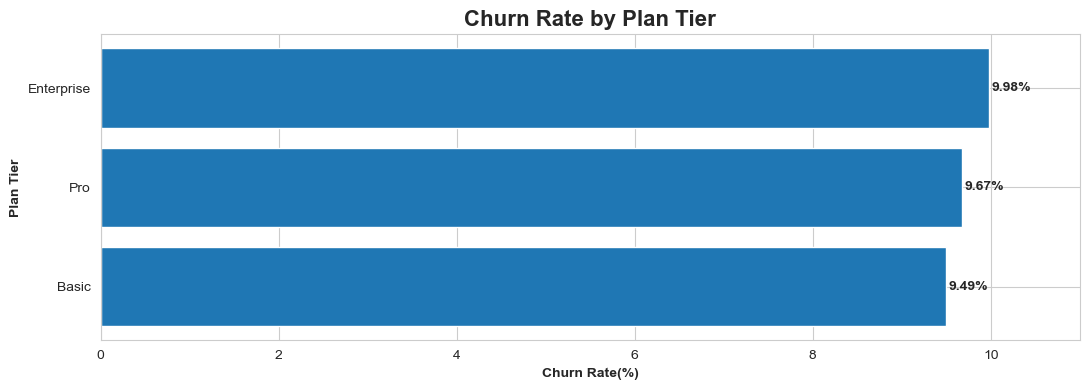

In [12]:
#sorting from by churn rate
churn_by_tier_sorted = churn_by_tier.sort_values('churn_rate')
sns.set_style('whitegrid')

#creating horizontal bar graph showing diffference in churn rate
fig, ax = plt.subplots(figsize =(11,4))

ax.barh(churn_by_tier_sorted.index,churn_by_tier_sorted['churn_rate'])
ax.set_title('Churn Rate by Plan Tier', fontsize = 16, fontweight='bold')
ax.set_ylabel('Plan Tier',fontweight = 'bold')
ax.set_xlabel('Churn Rate(%)', fontweight = 'bold')
ax.set_xlim(0,11)

#adding churn rate next to each bar
for i, rate in enumerate(churn_by_tier_sorted['churn_rate']):
    ax.text(rate +.03, i, f'{rate}%', va = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()

In [13]:
#Fiilter only churned accounts
acc_churn = account[account['churn_flag'] == True]

#since accounts can be churned then reinstated then churned again, this takes most common reason 
churn_reason = churn.groupby('account_id')['reason_code'].agg(lambda x: x.mode()[0]).reset_index()

#merges 2 datasets to add reason_code to acc_churn
acc_churn_reason = pd.merge(acc_churn, churn_reason[['account_id','reason_code']],on='account_id',how='left')
acc_churn_reason.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,reason_code
0,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,NaN
1,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,budget
2,A-7dacce,Company_8,Cybersecurity,CA,2024-09-10,event,Enterprise,12,False,True,budget
3,A-10b8da,Company_9,DevTools,US,2023-05-08,partner,Enterprise,14,False,True,NaN
4,A-592832,Company_10,Cybersecurity,US,2024-09-25,organic,Basic,18,False,True,support


In [14]:
#fills null values with "no recorded reason
acc_churn_reason['reason_code'] = acc_churn_reason['reason_code'].fillna('no recorded reason')

In [15]:
#group the account tier with the most used reason for churning
acc_reason_by_tier = acc_churn_reason.groupby(['plan_tier','reason_code']).size()
acc_reason_by_tier

plan_tier   reason_code       
Basic       budget                 6
            competitor             3
            features               4
            no recorded reason    13
            pricing                4
            support                7
Enterprise  budget                 9
            competitor             2
            features               5
            no recorded reason     9
            pricing                4
            support                3
            unknown                2
Pro         budget                 9
            competitor             5
            features               4
            no recorded reason    13
            pricing                4
            support                3
            unknown                1
dtype: int64

In [16]:
basic = acc_reason_by_tier.loc['Basic'].sort_values(ascending =False)
pro = acc_reason_by_tier.loc['Pro'].sort_values(ascending = False)
enterprise = acc_reason_by_tier.loc['Enterprise'].sort_values(ascending = False)



Text(0.5, 0, 'Reason for Churning')

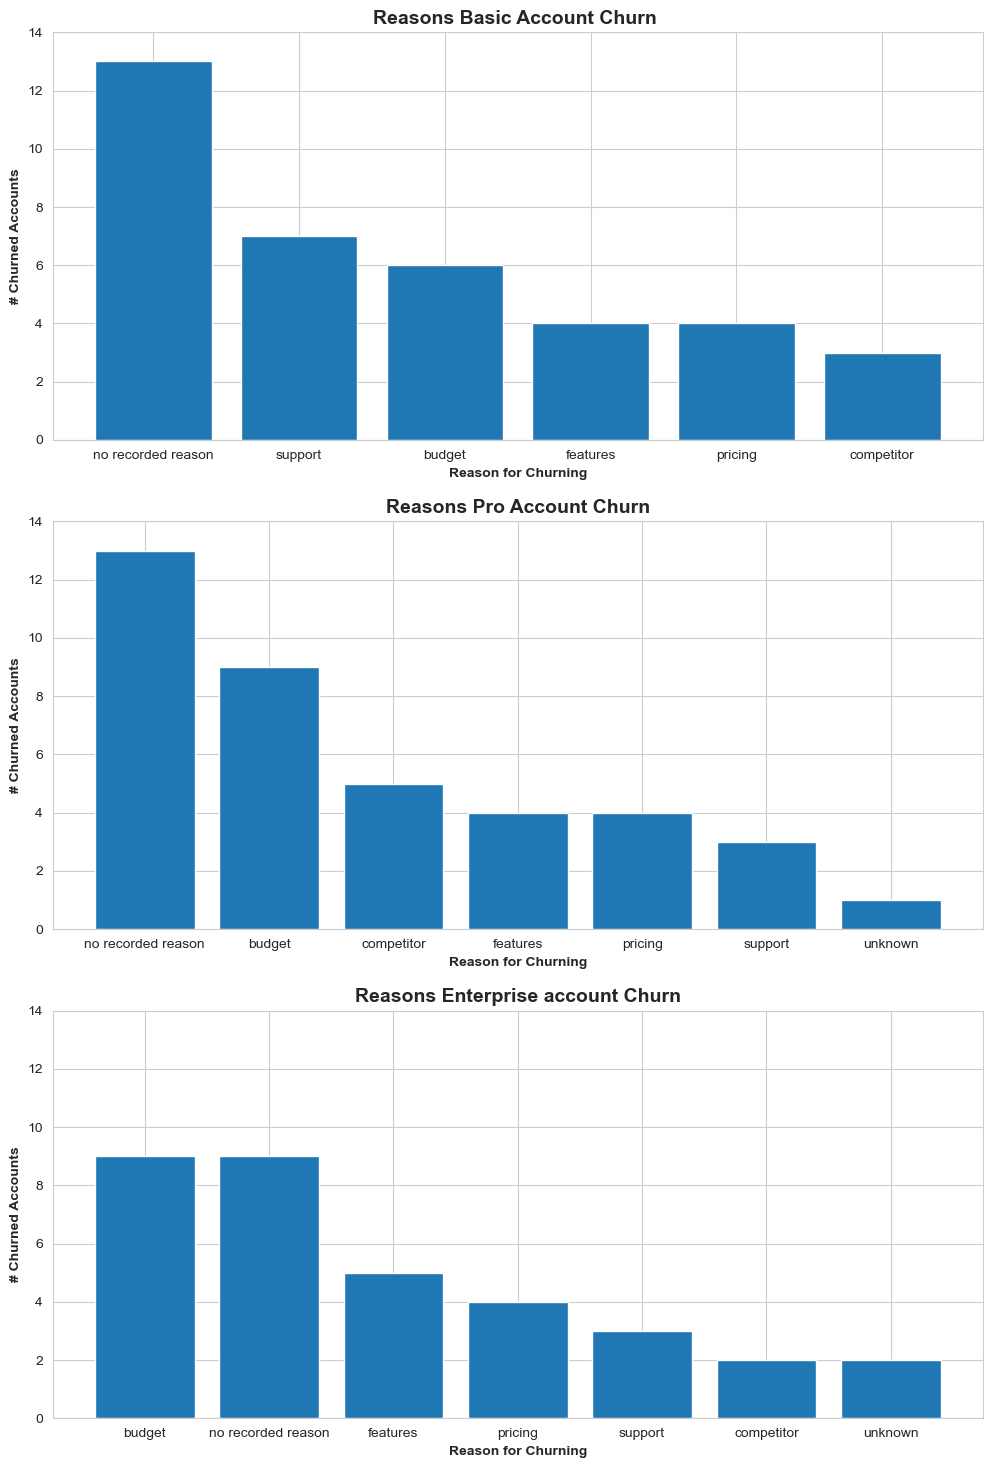

In [79]:
fig,axes = plt.subplots(3,1, figsize=(12,18))

axes[0].bar(basic.index, basic)
axes[0].set_title('Reasons Basic Account Churn ', fontweight = 'bold', fontsize =14)
axes[0].set_ylim((0,14))
axes[0].set_ylabel('# Churned Accounts', fontweight ='bold')
axes[0].set_xlabel('Reason for Churning', fontweight = 'bold')

axes[1].bar(pro.index, pro)
axes[1].set_title('Reasons Pro Account Churn', fontweight = 'bold', fontsize = 14)
axes[1].set_ylim((0,14))
axes[1].set_ylabel('# Churned Accounts', fontweight = 'bold')
axes[1].set_xlabel('Reason for Churning', fontweight = 'bold')

axes[2].bar(enterprise.index, enterprise)
axes[2].set_title('Reasons Enterprise account Churn', fontweight = 'bold', fontsize = 14)
axes[2].set_ylim((0,14))
axes[2].set_ylabel('# Churned Accounts', fontweight = 'bold')
axes[2].set_xlabel('Reason for Churning', fontweight = 'bold')


## Subscription Churn Rate by Reason

**Business Question:** 

1. What reasons are driving customers to Unsubscribe?
2. What are reason customers with different subscriptions are leaving? 

**Finding:** 

1. Analyzing customer feedback text revealed three reasons customers cited for leaving: price/cost (35.62%), missing features (34.29%), and switching to a competitor (30.09%). When cross referencing against the reason codes in the churn events table, missing features appeared as the single largest individual code. However, when combining the budget and pricing reason codes — two separate codes that both relate to cost — price-related churn accounts for roughly 1 in 3 churned customers, making it the single largest driver of churn overall.
2. When segmenting price-related churn by plan tier, Pro and Enterprise subscribers are disproportionately affected. Of all Pro subscribers who churned, approximately 40% cited price as their reason. Of all Enterprise subscribers who churned, approximately 35% did the same. This suggests higher tier customers may not feel they are getting sufficient value for their subscription cost or it is too expensive.
3. Pro and Enterprise subscribers who churned due to price together account for approximately 21% of all churned customers. This makes price dissatisfaction among higher tier customers one of the most concentrated and actionable retention opportunities in the dataset.

**Recommendations**

1.  Have data collection team collect more data on users who leave due to price-related reasons. Specifically, the exit survey should include a targeted question such as: "Is the price outside of your current budget, or do you feel the product does not justify the cost?" This distinction is important because the two situations require completely different responses — one is an affordability problem, the other is a perceived value problem. 
2. We should explore retention strategies specifically targeting customers who are ending their subscription due to price. One example would be offering a temporary discount to customers who cite price as their primary churn reason during the cancellation flow. This could help retain the customer until either the product's feature set improves to a level they consider worth the price, or they are able to get budget approved internally.

**Next Steps**

1. Separate churn reasons by industry to determine whether different industries are churning for different reasons. For example, understanding whether DevTools customers are leaving due to missing features while HealthTech customers are leaving due to competitors would allow the business to develop targeted retention strategies for each segment rather than a one-size-fits-all approach.




**Note:** 
This analysis examines price-related churn at the subscription level, not the account level. One account may have multiple subscriptions, so these percentages reflect subscription volume rather than unique customer counts.


In [19]:
#creating new 'churn_by_reason' dataframe which includes the churn count and churn rate of each 'reason code' 
churn_by_reason = pd.DataFrame({
    'churn_count': churn['reason_code'].value_counts(),
    'churn_rate': (churn['reason_code'].value_counts(normalize=True)).round(4)*100
})

print(churn_by_reason)

             churn_count  churn_rate
reason_code                         
features             114       19.00
support              104       17.33
budget               104       17.33
unknown               95       15.83
competitor            92       15.33
pricing               91       15.17


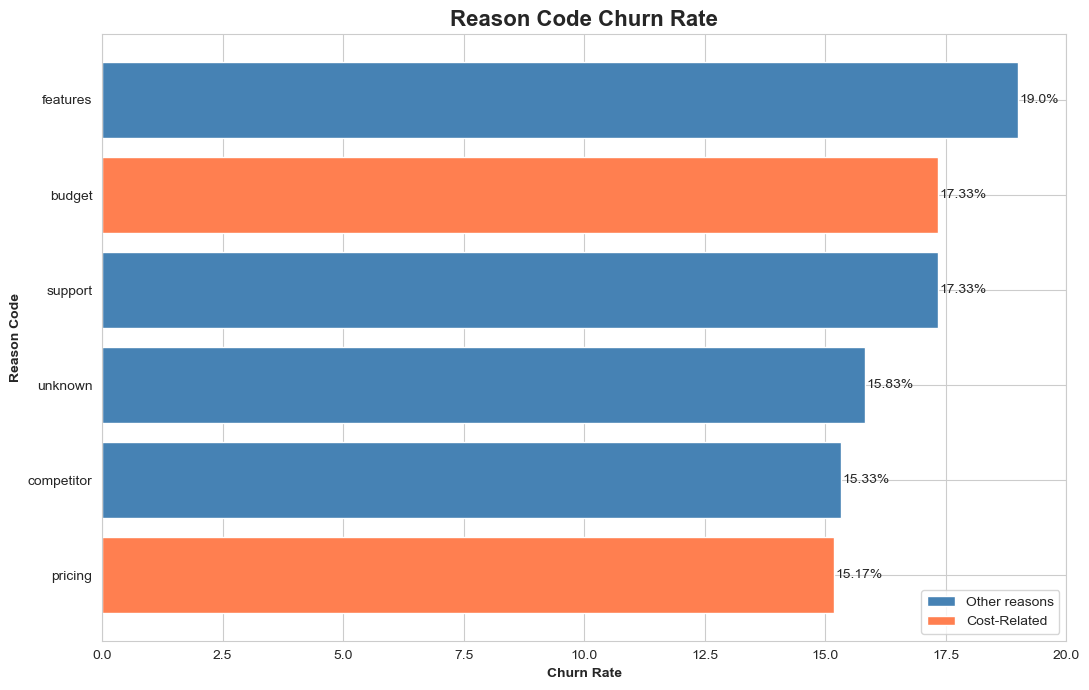

In [20]:
#sorting 'churn_by_reason' by churn rate
churn_by_reason = churn_by_reason.sort_values('churn_rate')

#changing color scheme for bargraph which separates monetary reasons(coral) from the rest(steelblue)
colors = ['coral' if (item == 'budget') or (item == 'pricing') else 'steelblue' for item in churn_by_reason.index]

#creating a legend for the graph
legend_elements = [
    Patch(facecolor = 'steelblue', label = 'Other reasons'),
    Patch(facecolor= 'coral', label = 'Cost-Related')
]

#creating bar graph with labels 
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (11,7))

ax.barh(churn_by_reason.index, churn_by_reason['churn_rate'], color = colors)
ax.set_title('Reason Code Churn Rate', fontsize = 16, fontweight = 'bold')
ax.set_xlabel('Churn Rate', fontweight = 'bold')
ax.set_ylabel('Reason Code', fontweight = 'bold')
ax.set_xlim(0,20)
ax.legend(handles = legend_elements, loc='lower right')

#adding percentages next to respective bar for clarity
for i, rate in enumerate(churn_by_reason['churn_rate']):
    rate = round(rate,4)
    ax.text(rate + .03, i, f'{rate}%', verticalalignment = 'center')

plt.tight_layout()
plt.show()

In [21]:
#filtering 'churn reasons' for rows which have feedback
churn_reasons = churn[churn['has_feedback'] == True]

#checking the unique values for the feedback that people provide
unique_feedback =  churn_reasons['feedback_text'].unique()
print(unique_feedback)

['switched to competitor' 'missing features' 'too expensive']


In [22]:
#creating dataframe which has the count of different feedback reasons and the percent of feedback that each reason accounts for
churn_by_feedback = pd.DataFrame({
    'churn_feedback_count': churn['feedback_text'].value_counts(),
    'churn_feedback_rate': (churn['feedback_text'].value_counts(normalize=True)).round(4)*100
})

print(churn_by_feedback)

                        churn_feedback_count  churn_feedback_rate
feedback_text                                                    
too expensive                            161                35.62
missing features                         155                34.29
switched to competitor                   136                30.09


In [23]:
#joining the 'subs' and 'churn reasons' table to create 'sub_churn (just adding 'feedback_text' to the subs table) 
sub_churn = pd.merge(subs,churn_reasons[['account_id','feedback_text']], on='account_id', how='left')

#filtering the 'sub_churn' dataframe to only include 'too expensive' as the reason and only subscriptions which have churnned
sub_churn  = sub_churn[(sub_churn['feedback_text'] == 'too expensive') & (sub_churn['churn_flag'] == True)]

#creating sub_feedback  which is the 'sub_churn' dataframe but provides the count of each plan tier grouped with its 'feedback_text'
sub_feedback  = sub_churn.groupby('plan_tier')['feedback_text'].agg(total='count')

#putting the total number of churned subscribers which churned into a variable
total_too_expensive = sub_churn['plan_tier'].value_counts().sum()

#Creating dataframe with different information about churned subscribers separated by plan tier 
sub_feedback_expense = pd.DataFrame({
    'too_expensive_count': sub_churn['plan_tier'].value_counts(),
    'total_subs': churn_by_tier['total'],
    'tier_churn_rate': ((sub_churn['plan_tier'].value_counts()/churn_by_tier['total']).round(4)*100),
    'share_of_price_churns':(sub_churn['plan_tier'].value_counts()/total_too_expensive).round(4)*100,
    'relative_to_tier_churns':(sub_churn['plan_tier'].value_counts()/churn_by_tier['churned']).round(4)*100,
    'relative_to_all_churns':(sub_churn['plan_tier'].value_counts()/len(churn)).round(4)*100,
    'relative_to_all_churns_who_gave_feedback':(sub_churn['plan_tier'].value_counts()/churn_by_feedback['churn_feedback_count'].sum()).round(4)*100
})
print(sub_feedback_expense)

            too_expensive_count  total_subs  tier_churn_rate  \
plan_tier                                                      
Basic                        45        1602             2.81   
Enterprise                   61        1723             3.54   
Pro                          65        1675             3.88   

            share_of_price_churns  relative_to_tier_churns  \
plan_tier                                                    
Basic                       26.32                    29.61   
Enterprise                  35.67                    35.47   
Pro                         38.01                    40.12   

            relative_to_all_churns  relative_to_all_churns_who_gave_feedback  
plan_tier                                                                     
Basic                         7.50                                      9.96  
Enterprise                   10.17                                     13.50  
Pro                          10.83                  

## Account Churn rate by Industry

**Business Question:**

1. Accounts from which industries are churning the most?
2. Why are those accounts churning?

**Findings:**

1. When looking strictly at accounts, DevTools makes up the largest percentage of churned accounts at 31.8%. FinTech and HealthTech follow at 22.7% and 19.1% respectively.
2. In addition to making up the largest portion of churned accounts, DevTools also has the highest churn rate at 30.97%, followed again by FinTech and HealthTech at 22.32% and 21.88% respectively.
3. When looking at why these accounts are churning, "Budget" was the most cited reason across nearly all industries with a significant gap between it and the remaining reasons. Features, Support, and Pricing were all cited at similar rates across churned customers.
4. The combined budget and pricing churns for DevTools alone (15 accounts) exceed the total known-reason churns for any other single industry, making it the highest priority segment for cost-related retention efforts.
5. A significant data gap exists — "no recorded reason" is the largest single category across all industries, representing 35 out of 110 churned accounts. This limits our ability to draw confident conclusions about churn drivers across all segments.
6. FinTech accounts have 12 out of 25 churns with no recorded reason (48%), the highest rate of missing data of any industry. They also have zero pricing-related churns among their recorded reasons, suggesting pricing may not be a primary driver for this group — however, given the volume of missing data, this conclusion cannot be confirmed.
7. EdTech and FinTech accounts cited features as one of the main reasons for churning among their recorded reasons.

**Recommendations:**

1. Incentivize churned accounts to record their reasons for leaving. The current data gap — particularly in FinTech and HealthTech — prevents confident conclusions and limits the effectiveness of targeted retention strategies.
2. Focus on DevTools pricing by introducing personalized subscription tiers. Given that cost-related churns dominate this segment, consider a survey to determine whether the issue is affordability or perceived value:

        a. If affordability is the issue, offer a more targeted subscription removing features they rarely use at a lower price point.
   
        b. If perceived value is the issue, focus on improving or expanding features most relevant to DevTools workflows.



3. Develop new features targeting FinTech and EdTech customers, both of whom cited features as a top churn reason. This should be treated as a secondary priority given their smaller share of total churned accounts.

**Next Steps:**

1. Investigate whether preceding downgrades serve as an early warning signal for churn — accounts that downgrade before cancelling may represent a high-priority intervention opportunity.
2. Analyze feature usage data to identify which features churned customers were not engaging with before leaving, which could clarify whether "missing features" refers to undiscovered existing features or genuinely absent ones.

In [25]:
#filtering accounts(not subscriptions(can be multiple subscriptions per account)) to only have churned accounts
churned_accounts = account[account['churn_flag'] == True]

#grouping the accounts by industry and getting the count
churned_accounts_by_industry = churned_accounts.groupby('industry')['churn_flag'].agg(total='count')
total_acc_churned = churned_accounts_by_industry['total'].sum()
churned_accounts_by_industry = churned_accounts_by_industry.sort_values('total', ascending = False)
print(churned_accounts_by_industry)

               total
industry            
DevTools          35
FinTech           25
HealthTech        21
Cybersecurity     16
EdTech            13


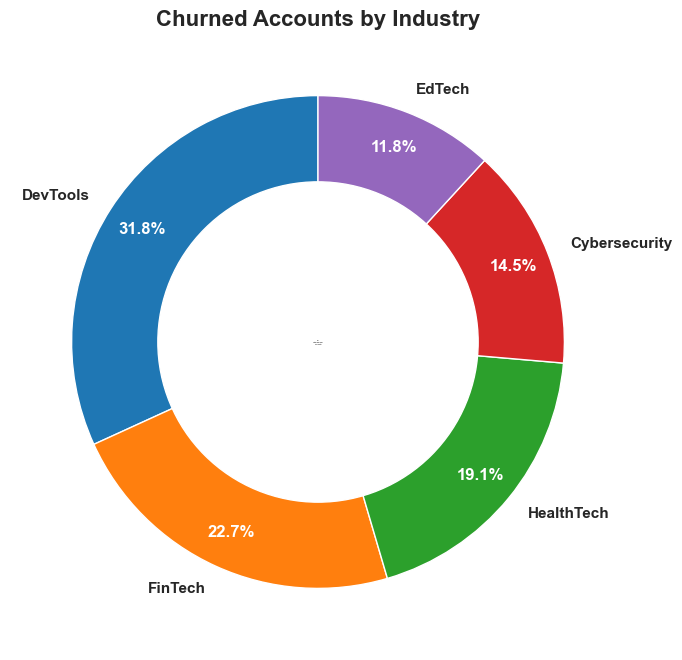

In [26]:
fig,ax = plt.subplots(figsize=(8,8))

#creating a pie chart for the account and industry churn rates
wedges, texts, autotexts = ax.pie(
    churned_accounts_by_industry['total'],
    labels = churned_accounts_by_industry.index,
    autopct ='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

#making industry percentages more visible
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

#making industry names more visible
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

#making pie chart into donut chart
ax.set_title('Churned Accounts by Industry', fontsize = 16, fontweight = 'bold')
center_circle = plt.Circle((0,0),0.65, fc = 'white')
ax.add_artist(center_circle)

#adding text ot center
ax.text(0,0, f'110\nTotal Churned \nAccounts', ha='center', va = 'center', fontsize = 1, fontweight= 'bold')

plt.show()


In [27]:
#get the total number of accounts by industry
total_accounts_by_industry = account.groupby('industry')['account_id'].agg(total = 'count')
print(total_accounts_by_industry)

               total
industry            
Cybersecurity    100
DevTools         113
EdTech            79
FinTech          112
HealthTech        96


In [28]:
#create a dataframe with the total, churned, and churn rate of accounts by industry
account_churn_by_industry = pd.DataFrame({
    'total': total_accounts_by_industry['total'],
    'churned': churned_accounts_by_industry['total'],
    'churn rate': ((churned_accounts_by_industry['total']/total_accounts_by_industry['total']).round(4))*100
})

#sort values 
account_churn_by_industry = account_churn_by_industry.sort_values('churn rate')
print(account_churn_by_industry)

               total  churned  churn rate
industry                                 
Cybersecurity    100       16       16.00
EdTech            79       13       16.46
HealthTech        96       21       21.88
FinTech          112       25       22.32
DevTools         113       35       30.97


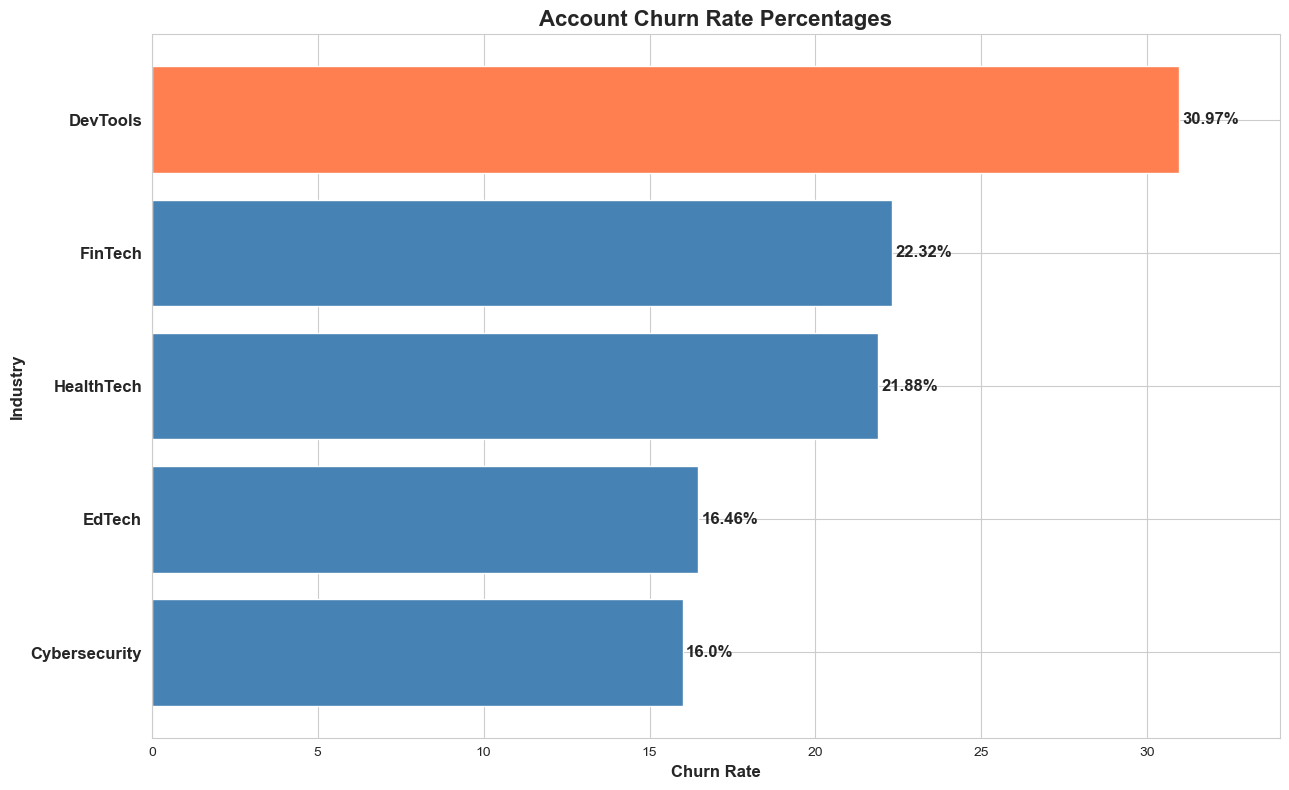

In [29]:
#create a horizontal bar chart
fig, ax =  plt.subplots(figsize = (13,8))

#make devtools a different color since it has highest churn rate 
colors = ['coral' if (i == 'DevTools') else 'steelblue' for i in account_churn_by_industry.index]

#making graph clearer 
ax.barh(account_churn_by_industry.index,account_churn_by_industry['churn rate'], color = colors)
ax.set_title('Account Churn Rate Percentages', fontsize = 16,fontweight = 'bold')
ax.set_xlim((0,34))
ax.set_xlabel('Churn Rate', fontsize = 12,fontweight = 'bold')
ax.set_ylabel('Industry', fontsize = 12, fontweight = 'bold')

#adding percents to chart 
for i,rate in enumerate(account_churn_by_industry['churn rate']):
    rate =  round(rate, 4)
    ax.text(rate +.1, i, f'{rate}%', verticalalignment = 'center', fontsize = 12, fontweight = 'bold')

#making labels more visible
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.tight_layout()
plt.show()

In [30]:
#get the most common reason code and group with account since one account can  have multiple subscriptions and hence multiple reason codes
churn_reason = churn.groupby('account_id')['reason_code'].agg(lambda x: x.mode()[0]).reset_index()
churn_reason.shape

(352, 2)

In [31]:
churn_reason.head()

,account_id,reason_code
0,A-00bed1,unknown
1,A-016043,competitor
2,A-029f69,competitor
3,A-02cd81,pricing
4,A-02fac6,support


In [32]:
#filtering accounts to only have accounts which have churned
acc_churn = account[account['churn_flag'] == True]

#merging the filtered accounts to include the reason code and setting null values as 'no recorded reason'
accounts_churns = pd.merge(acc_churn, churn_reason[['account_id', 'reason_code']],on='account_id', how='left')
accounts_churns['reason_code'] = accounts_churns['reason_code'].fillna('no recorded reason')
accounts_churns.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,reason_code
0,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,no recorded reason
1,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,budget
2,A-7dacce,Company_8,Cybersecurity,CA,2024-09-10,event,Enterprise,12,False,True,budget
3,A-10b8da,Company_9,DevTools,US,2023-05-08,partner,Enterprise,14,False,True,no recorded reason
4,A-592832,Company_10,Cybersecurity,US,2024-09-25,organic,Basic,18,False,True,support


In [33]:
accounts_churns.shape

(110, 11)

In [34]:
#Getting the accounts which are churned and grouping by industry and reason code
industry_reason = accounts_churns.groupby(['industry','reason_code']).size()
industry_reason

industry       reason_code       
Cybersecurity  budget                 5
               competitor             1
               features               1
               no recorded reason     5
               pricing                2
               support                2
DevTools       budget                 8
               competitor             4
               features               3
               no recorded reason     7
               pricing                7
               support                5
               unknown                1
EdTech         budget                 1
               competitor             1
               features               4
               no recorded reason     3
               pricing                1
               support                3
FinTech        budget                 5
               competitor             2
               features               4
               no recorded reason    12
               support                1
      

In [35]:
#convert to wide data for stacked bar graph
industry_reason_wide = industry_reason.unstack(level='reason_code')

#zero out all columns
industry_reason_wide = industry_reason_wide.fillna(0)

#sorting industries from most churned accounts to least
industry_reason_wide['total'] = industry_reason_wide.sum(axis=1)
industry_reason_wide = industry_reason_wide.sort_values('total', ascending=False)
industry_reason_wide = industry_reason_wide.drop(columns='total')

# reordering columns to get monetary issues together. Also get unknown and no recorded reason together
column_order = ['budget', 'pricing', 'competitor', 'features', 'support', 'unknown', 'no recorded reason']
industry_reason_wide = industry_reason_wide[column_order]

# Verify the numbers add up to what we had before
print(industry_reason_wide.sum(axis=1))

industry
DevTools         35.0
FinTech          25.0
HealthTech       21.0
Cybersecurity    16.0
EdTech           13.0
dtype: float64


In [36]:
industry_reason_wide.shape

(5, 7)

In [37]:
print(accounts_churns['reason_code'].isna().sum())
print(accounts_churns.shape)

0
(110, 11)


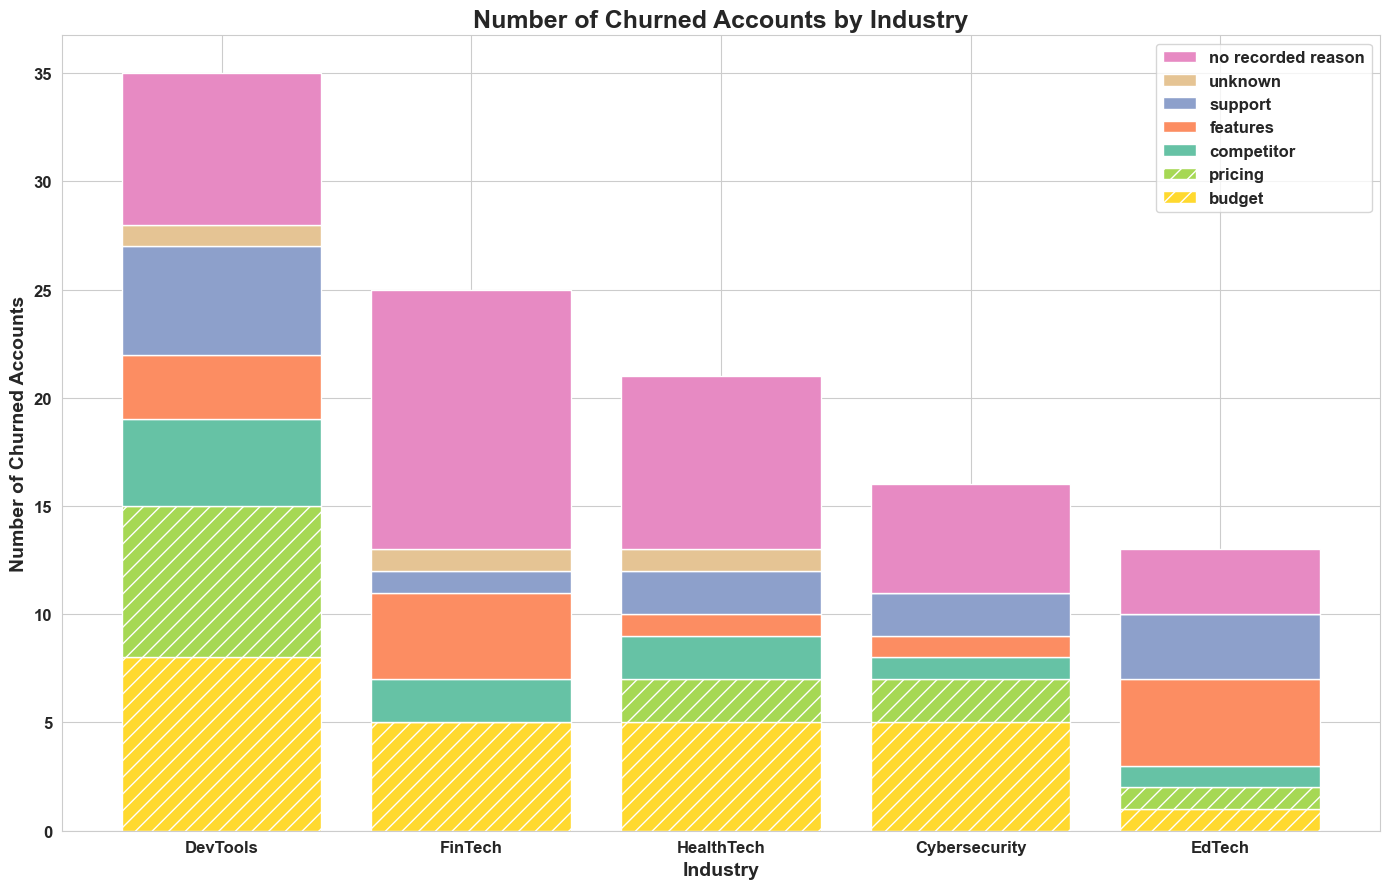

In [38]:
fig, ax = plt.subplots(figsize =(14,9))

#cloumn order
column_order = ['budget', 'pricing','competitor', 'features', 'support','unknown', 'no recorded reason']
industry_reason_wide = industry_reason_wide[column_order]

#setting bar starting point
bottom = np.zeros(len(industry_reason_wide))

#choosing colors
colors = sns.color_palette('Set2', n_colors=7)
color_map = {
    'competitor': colors[0],
    'features': colors[1],
    'support': colors[2],
    'no recorded reason': colors[3],
    'unknown': colors[6],
    'budget': colors[5],
    'pricing': colors[4]  
}

#stacked bar graph
for reason in industry_reason_wide.columns:
    hatch = '//' if (reason == 'pricing') or (reason == 'budget') else None
    ax.bar(industry_reason_wide.index, 
           industry_reason_wide[reason],
           bottom = bottom,
           color= color_map[reason],
           hatch = hatch,
           label = reason)
    bottom += industry_reason_wide[reason].values

ax.set_xlabel('Industry', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Number of Churned Accounts', fontsize = 14, fontweight = 'bold')
ax.set_title('Number of Churned Accounts by Industry', fontsize = 18, fontweight = 'bold')

#altering x and y labels
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper right', prop={'weight': 'bold', 'size': 12})

    
plt.tight_layout()
plt.show()

In [39]:
#transposing industry_reason_wide to make new stacked bar chart
reason_industry_wide =   industry_reason_wide.T

#sorting reasons from most churned accounts to least
reason_industry_wide['total'] = reason_industry_wide.sum(axis=1)
reason_industry_wide = reason_industry_wide.sort_values('total', ascending=False)
reason_industry_wide = reason_industry_wide.drop(columns='total')


print(reason_industry_wide)

industry            DevTools  FinTech  HealthTech  Cybersecurity  EdTech
reason_code                                                             
no recorded reason       7.0     12.0         8.0            5.0     3.0
budget                   8.0      5.0         5.0            5.0     1.0
features                 3.0      4.0         1.0            1.0     4.0
support                  5.0      1.0         2.0            2.0     3.0
pricing                  7.0      0.0         2.0            2.0     1.0
competitor               4.0      2.0         2.0            1.0     1.0
unknown                  1.0      1.0         1.0            0.0     0.0


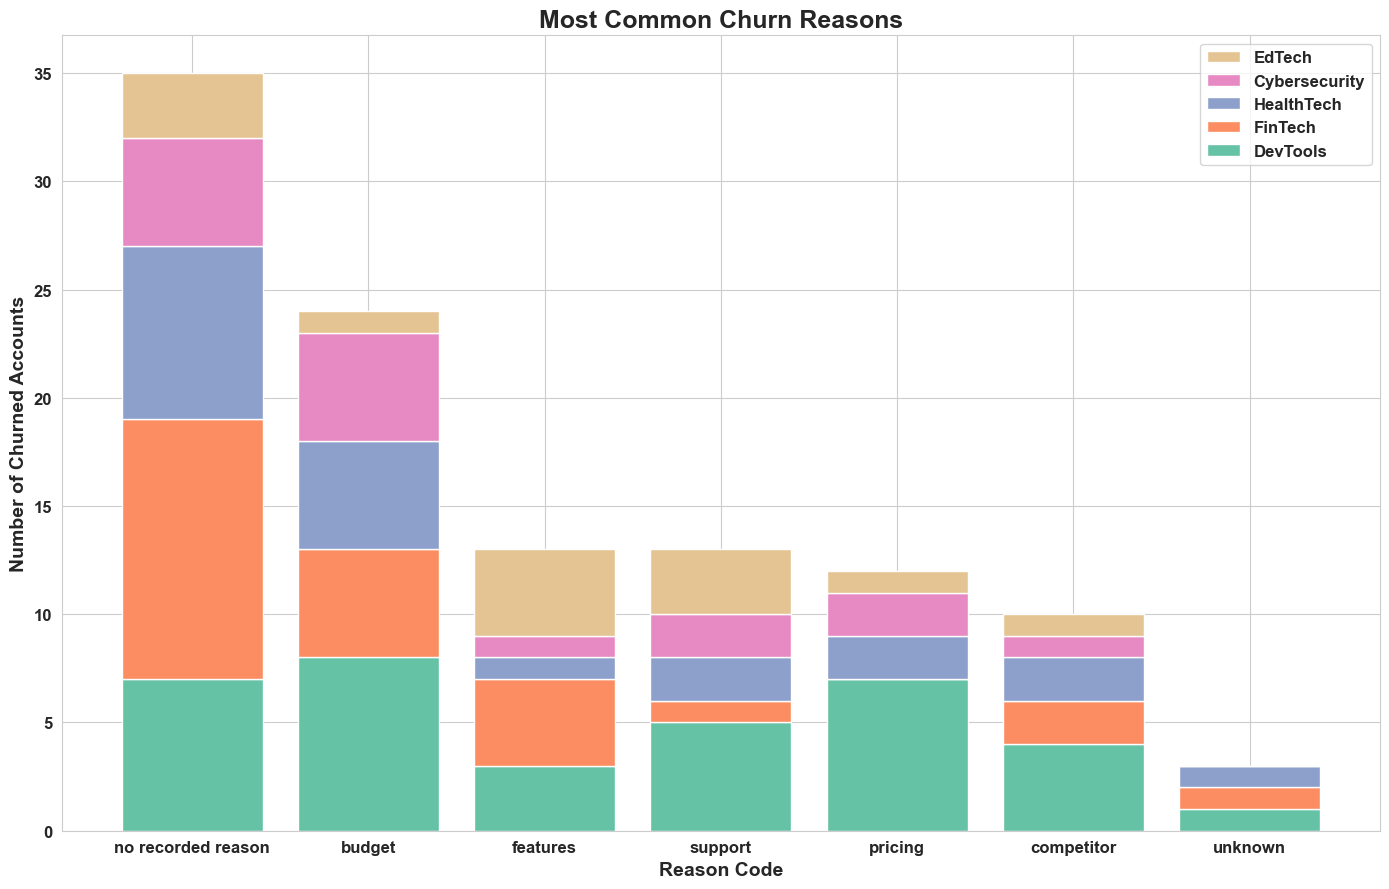

In [40]:
fig, ax = plt.subplots(figsize = (14,9))

#setting bar starting point
bottom = np.zeros(len(reason_industry_wide))

#choosing colors
color_map = {
    'DevTools': colors[0],
    'FinTech': colors[1],
    'HealthTech': colors[2],
    'Cybersecurity': colors[3],
    'EdTech': colors[6],
}

#stacked bar graph
for reason in reason_industry_wide.columns:
    ax.bar(reason_industry_wide.index, 
           reason_industry_wide[reason],
           bottom = bottom,
           color= color_map[reason],
           label = reason)
    bottom += reason_industry_wide[reason].values

ax.set_xlabel('Reason Code', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Number of Churned Accounts', fontsize = 14, fontweight = 'bold')
ax.set_title('Most Common Churn Reasons', fontsize = 18, fontweight = 'bold')

#altering x and y labels
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

#creates legend in same order as in bar graph
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper right', prop={'weight': 'bold', 'size': 12})

    
plt.tight_layout()
plt.show()
